frame=0.512s  f_min=0.0Hz  vote_frac=0.4  min_sep=0.5s  thresholds={'st': 0.3064076453447342, 'mt': 0.2659789174795151, 'bt': 0.2598496675491333}
Hour 1/72: 5 detections at alpha=1
Hour 2/72: 1 detections at alpha=1
Hour 3/72: 0 detections at alpha=1
Hour 4/72: 0 detections at alpha=1
Hour 5/72: 0 detections at alpha=1
Hour 6/72: 1 detections at alpha=1
Hour 7/72: 1 detections at alpha=1
Hour 8/72: 0 detections at alpha=1
Hour 9/72: 0 detections at alpha=1
Hour 10/72: 1 detections at alpha=1
Hour 11/72: 0 detections at alpha=1
Hour 12/72: 0 detections at alpha=1
Hour 13/72: 0 detections at alpha=1
Hour 14/72: 3 detections at alpha=1
Hour 15/72: 6 detections at alpha=1
Hour 16/72: 0 detections at alpha=1
Hour 17/72: 2 detections at alpha=1
Hour 18/72: 1 detections at alpha=1
Hour 19/72: 29 detections at alpha=1
Hour 20/72: 4 detections at alpha=1
Hour 21/72: 58 detections at alpha=1
Hour 22/72: 3 detections at alpha=1
Hour 23/72: 0 detections at alpha=1
Hour 24/72: 1 detections at alpha

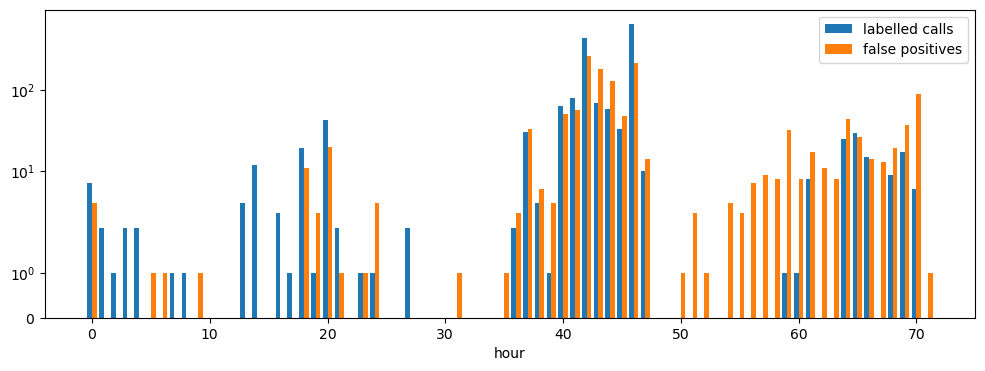

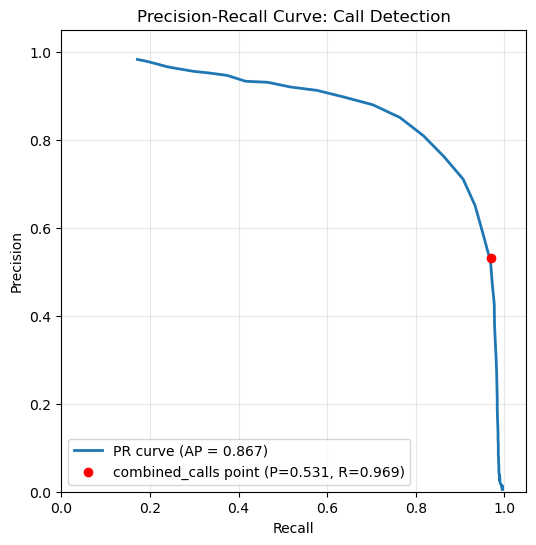

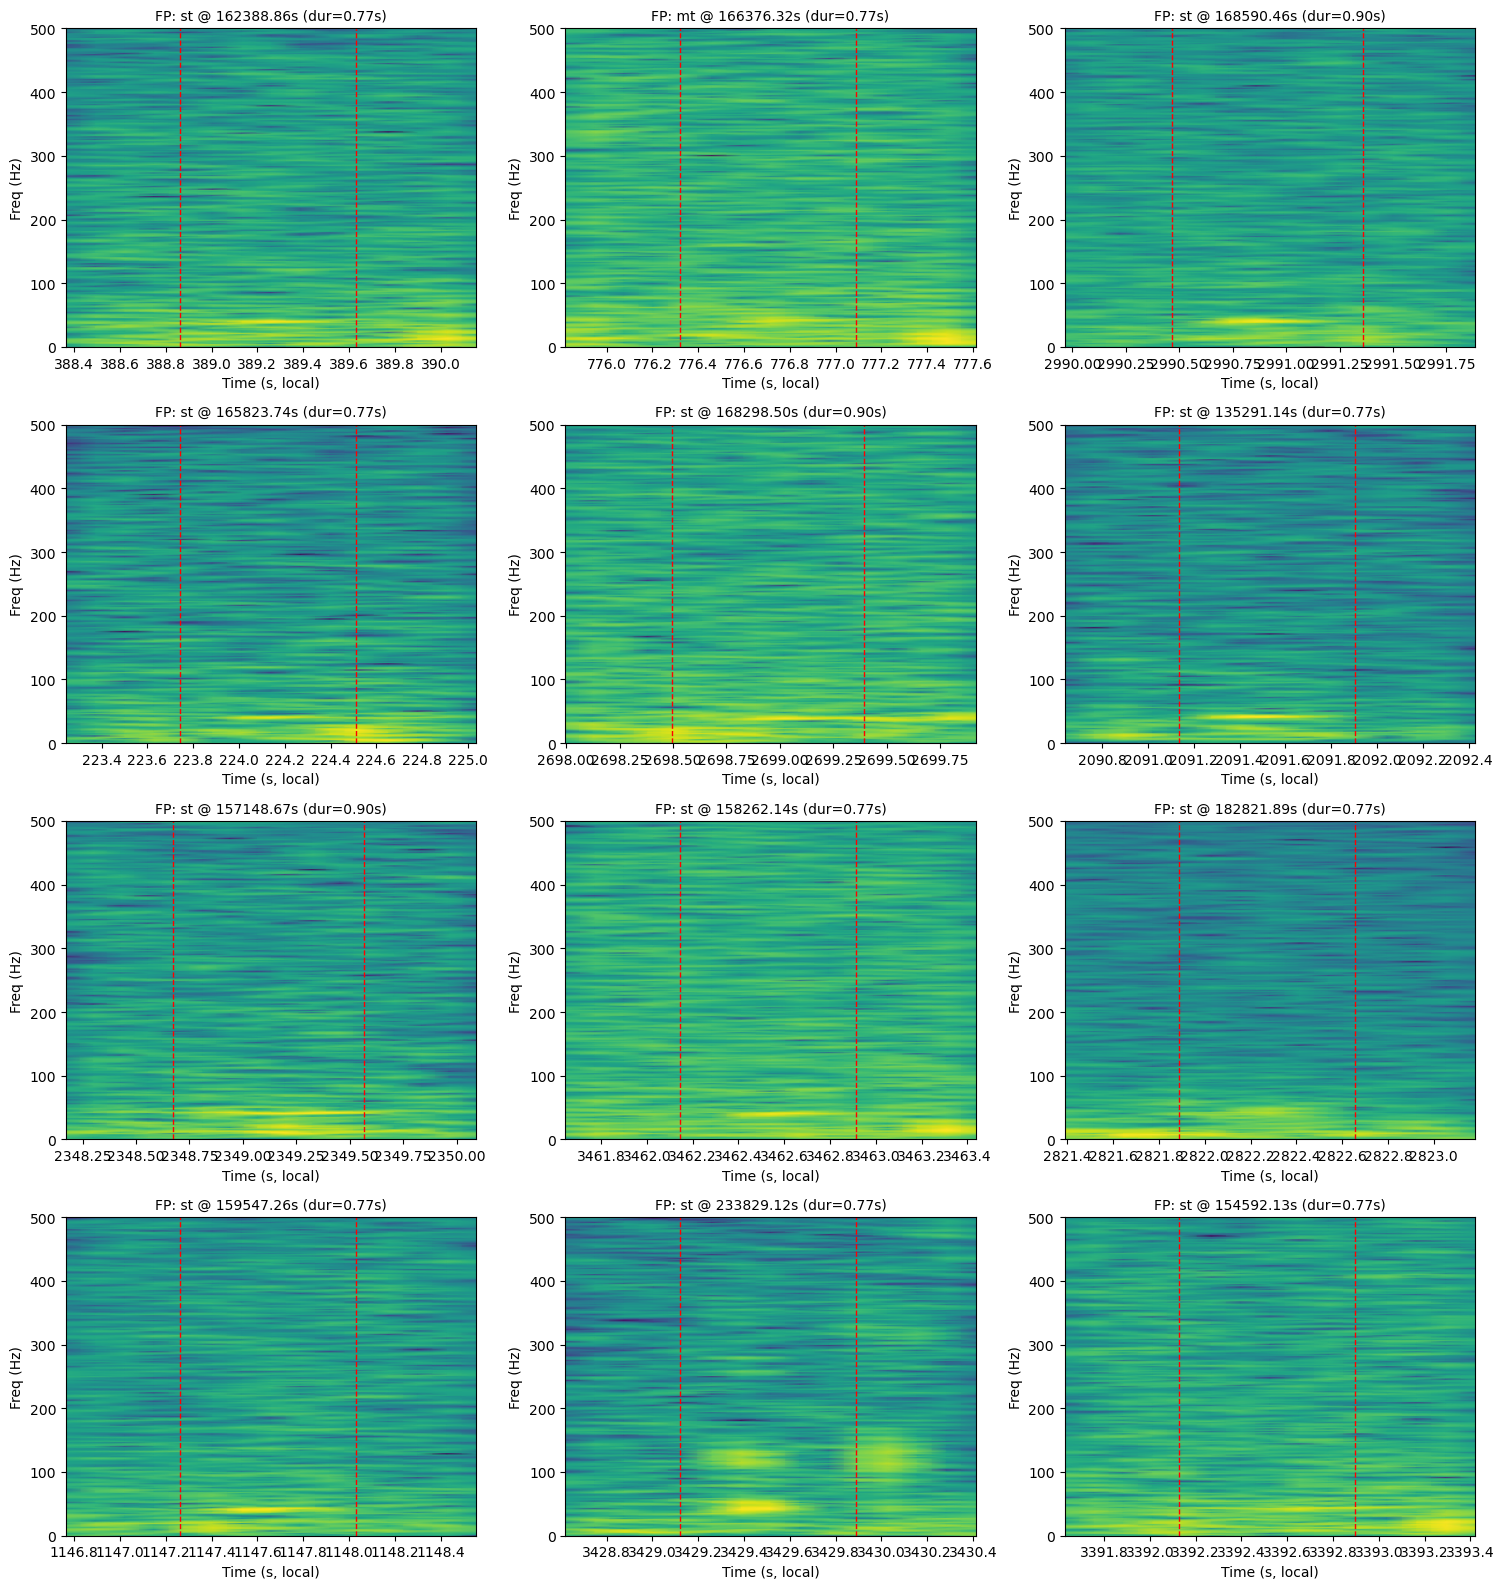

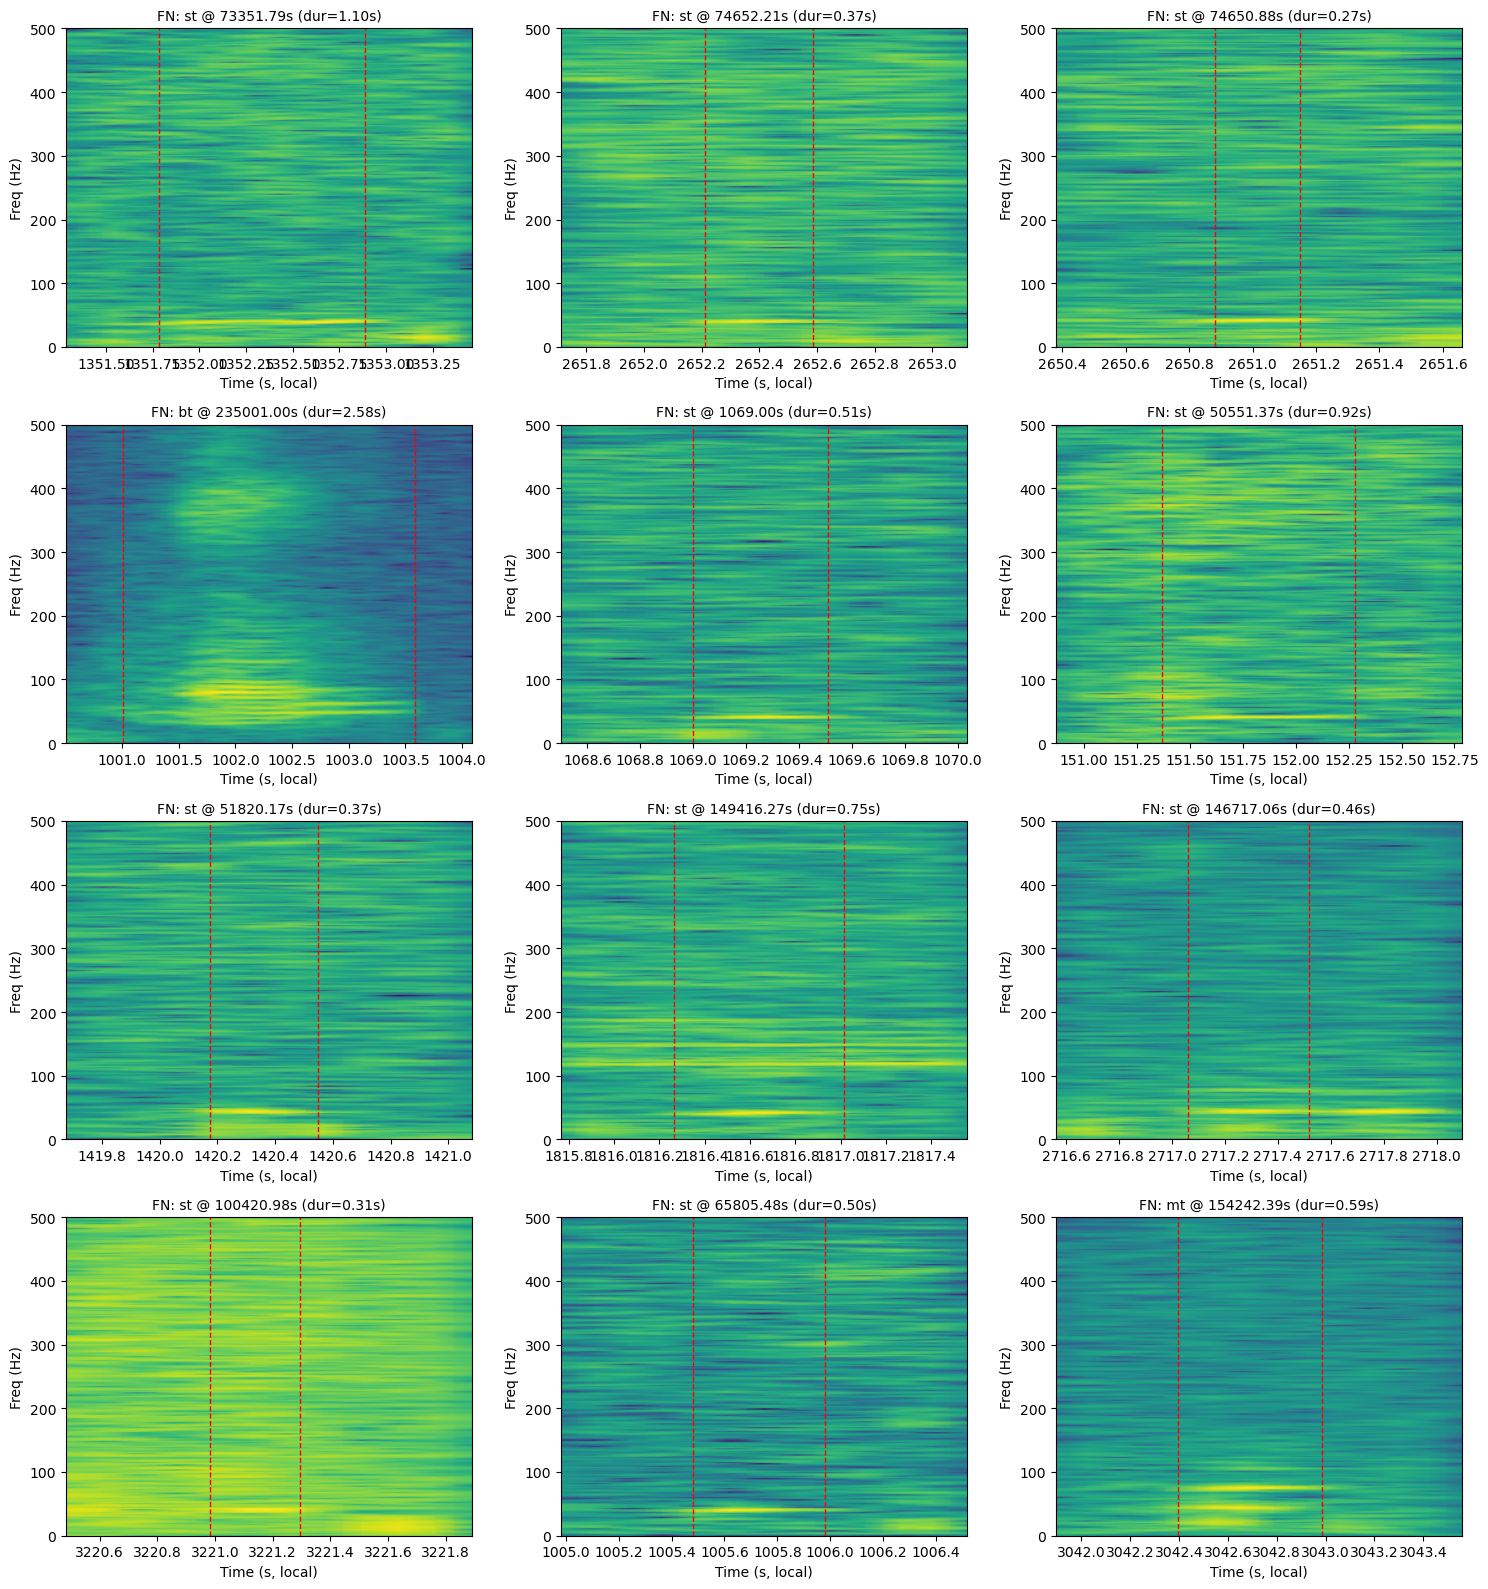

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from feature import make_stft_extractor
from testing import (
    load_raven_selection_table,
    get_exclusion_intervals,
    load_all_template_features_new,
    match_detections,
    compute_average_precision,
    plot_pr_curve,
    plot_detection_spectrograms,
)
from stream_detect import (
    load_stream_config, detect_stream, cands_to_calls, pr_sweep,
)

# ---------------- editable variables ----------------
feat_method = "stft"
n_temps = 10
n_hours = 72

RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"
DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
audio_file = DATA_22 / "20230422_171301.wav"

# ---------------- load calibration ----------------
cfg = load_stream_config(RESULTS / f"stream_config_{feat_method}_{n_temps}.json")
fs_new = cfg["fs_new"]
frame_len = cfg["frame_len"]
f_min = cfg.get("f_min", 0.0)
thresholds = cfg["thresholds"]
vote_frac = cfg["vote_frac"]
min_sep_s = cfg["min_sep_s"]
print(f"frame={frame_len}s  f_min={f_min}Hz  vote_frac={vote_frac}  min_sep={min_sep_s}s  thresholds={thresholds}")

extractor = make_stft_extractor(frame_dur=frame_len, f_min=f_min)
st_feats, mt_feats, bt_feats = load_all_template_features_new(
    results_dir=RESULTS_29, file_label="20230429_Templates", recording_label="20230429_102841",
    extractor=extractor, n_temps=n_temps, fs_new=fs_new,
)
templates = {"st": st_feats, "mt": mt_feats, "bt": bt_feats}

# ---------------- ground truth ----------------
raven_table = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(raven_table, exclude_labels=("td",), pad=0.1)
raven_table_no_td = [g for g in raven_table if g["label"] != "td"]

# ---------------- detect ----------------
cands = detect_stream(
    audio_file, n_hours, templates, thresholds, vote_frac, extractor, fs_new,
    min_sep_s=min_sep_s, exclude_intervals=td_intervals, alpha_max=3.0,
)

# deployed result at the calibrated thresholds (alpha = 1)
calls = cands_to_calls(cands, alpha=1.0)

tp, fp, fn, false_pos, false_neg = match_detections(calls, raven_table_no_td, ignore_duplicates=True)
p1, r1 = tp / (tp + fp), tp / (tp + fn)
print(f"deployed (alpha=1): calls={len(calls)}  P={p1:.3f}  R={r1:.3f}")

gt_s = np.array([g["start"] for g in raven_table_no_td])
gt_e = np.array([g["end"] for g in raven_table_no_td])
gaps = np.array([np.maximum(0, np.maximum(gt_s - e, s - gt_e)).min() for s, e, _ in false_pos])
print(f"False positives: {len(gaps)}")
print(f"  overlap an already-matched call (duplicates): {(gaps == 0).mean():.1%}")
print(f"  within 2 s of a labelled call:               {((gaps > 0) & (gaps < 2)).mean():.1%}")
print(f"  more than 2 s from any call (background):    {(gaps >= 2).mean():.1%}")


det_s = np.array([s for s, _, _ in calls])
fp_s = np.array([s for s, _, _ in false_pos])
hrs = np.arange(n_hours)
gt_h = np.bincount((gt_s // 3600).astype(int), minlength=n_hours)[:n_hours]
det_h = np.bincount((det_s // 3600).astype(int), minlength=n_hours)[:n_hours]
fp_h = np.bincount((fp_s // 3600).astype(int), minlength=n_hours)[:n_hours]
plt.figure(figsize=(12, 4))
plt.bar(hrs - 0.2, gt_h, width=0.4, label="labelled calls")
plt.bar(hrs + 0.2, fp_h, width=0.4, label="false positives")
plt.yscale("symlog")
plt.xlabel("hour")
plt.legend()
plt.show()

# ---------------- PR curve (sweep a common scale factor on all thresholds) ----------------
qs = np.quantile(cands["ratio"], np.geomspace(1e-3, 1.0, 60))
alphas = np.unique(np.append(qs[qs <= 3.0], [1.0, 2.0, 3.0]))
P, R, used = pr_sweep(cands, raven_table_no_td, alphas)
ap = compute_average_precision(P, R)
plot_pr_curve(P, R, ap=ap, marked_point=(p1, r1))

# ---------------- inspect errors ----------------
plot_detection_spectrograms(false_pos, audio_file, fs_new=fs_new,
                            framelength=int(fs_new * frame_len), n_examples=12, title_prefix="FP")
fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_neg]
plot_detection_spectrograms(fn_as_tuples, audio_file, fs_new=fs_new,
                            framelength=int(fs_new * frame_len), n_examples=12, title_prefix="FN")


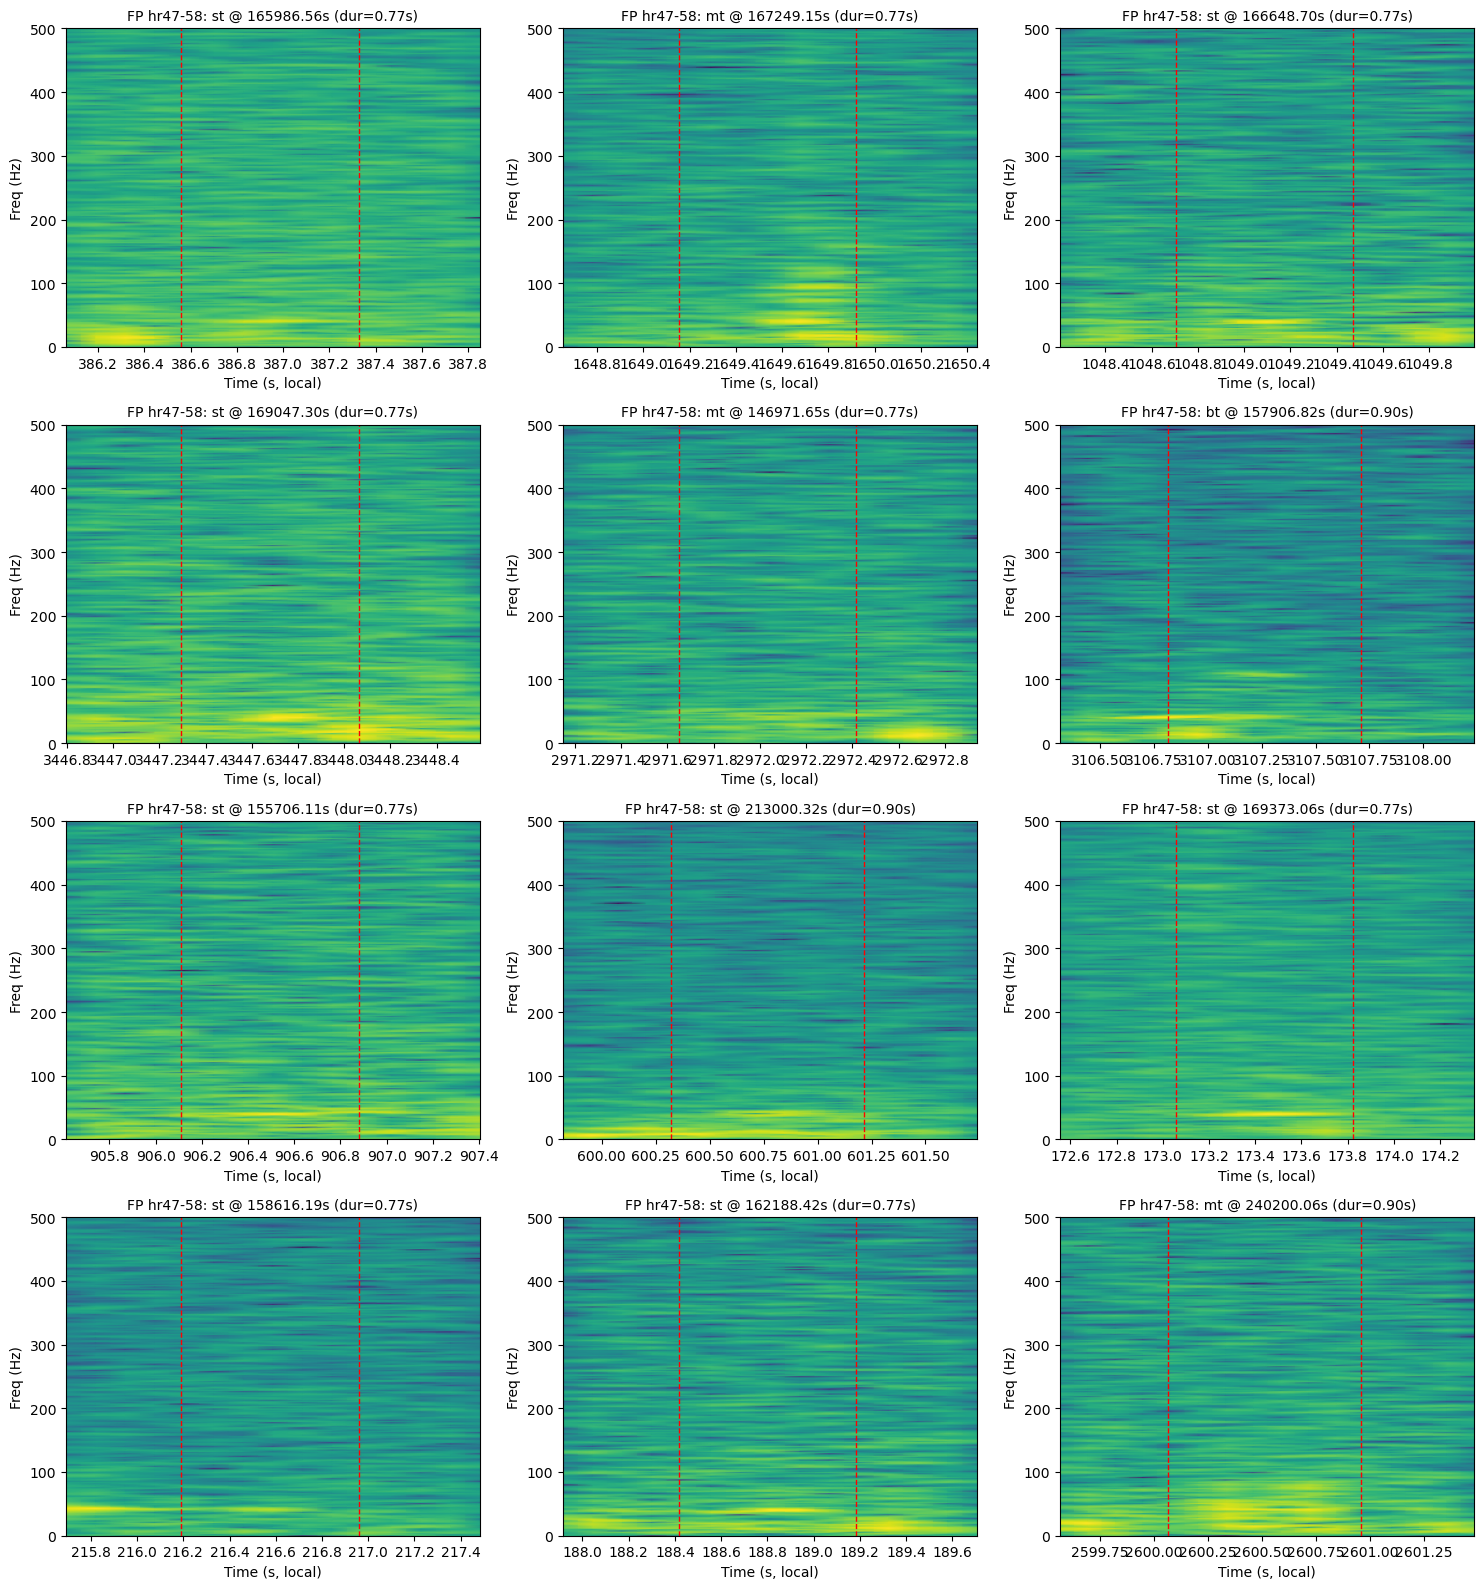

In [4]:
bad = [d for d in false_pos if 30 * 3600 <= d[0] < 72 * 3600]
plot_detection_spectrograms(bad, audio_file, fs_new=fs_new,
                            framelength=int(fs_new * frame_len), n_examples=12, title_prefix="FP hr47-58")